### Diabetes database

In [16]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [17]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
target = 'Outcome'

In [18]:
df = df.dropna(subset=['Outcome'])
df.shape

(768, 9)

In [19]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [21]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Feature columns:", list(X.columns))

Accuracy: 0.7922077922077922
Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [22]:
import os
OUTPUT_DIR = "outputs_diabetes"
os.makedirs(OUTPUT_DIR, exist_ok=True)

from sklearn.tree import export_graphviz
import graphviz
import shutil

dot = export_graphviz(
    model,
    out_file=None,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot)

if shutil.which("dot") is None:
    out_path = f"{OUTPUT_DIR}/diabetes_tree.dot"
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(dot)
    print("Graphviz not found in PATH. Saved DOT:", out_path)
else:
    graph.render(f"{OUTPUT_DIR}/diabetes_tree", format="png", cleanup=True)

### Diabetes — LIME Explanations


In [23]:
!pip install lime



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\hachimi\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [24]:
import lime
import lime.lime_tabular

# Diabetes has only numeric features — no categorical dummies
cat_feature_idx = []

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Diabetes', 'Diabetes'],
    categorical_features=cat_feature_idx,
    mode='classification',
    random_state=42,
    discretize_continuous=False
)


In [25]:
test_labels = y_test.reset_index(drop=True)
X_test_arr = X_test.values
feature_names_diab = X_train.columns.tolist()

# Pick one diabetic and one non-diabetic from the test set
diabetic_idx = test_labels[test_labels == 1].index[0]
no_diabetic_idx = test_labels[test_labels == 0].index[0]

print(f"Diabetic instance (test index {diabetic_idx}):")
print(dict(zip(feature_names_diab, X_test_arr[diabetic_idx])))
print(f"\nNon-diabetic instance (test index {no_diabetic_idx}):")
print(dict(zip(feature_names_diab, X_test_arr[no_diabetic_idx])))


Diabetic instance (test index 10):
{'Pregnancies': np.float64(10.0), 'Glucose': np.float64(111.0), 'BloodPressure': np.float64(70.0), 'SkinThickness': np.float64(27.0), 'Insulin': np.float64(0.0), 'BMI': np.float64(27.5), 'DiabetesPedigreeFunction': np.float64(0.141), 'Age': np.float64(40.0)}

Non-diabetic instance (test index 0):
{'Pregnancies': np.float64(6.0), 'Glucose': np.float64(98.0), 'BloodPressure': np.float64(58.0), 'SkinThickness': np.float64(33.0), 'Insulin': np.float64(190.0), 'BMI': np.float64(34.0), 'DiabetesPedigreeFunction': np.float64(0.43), 'Age': np.float64(43.0)}


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


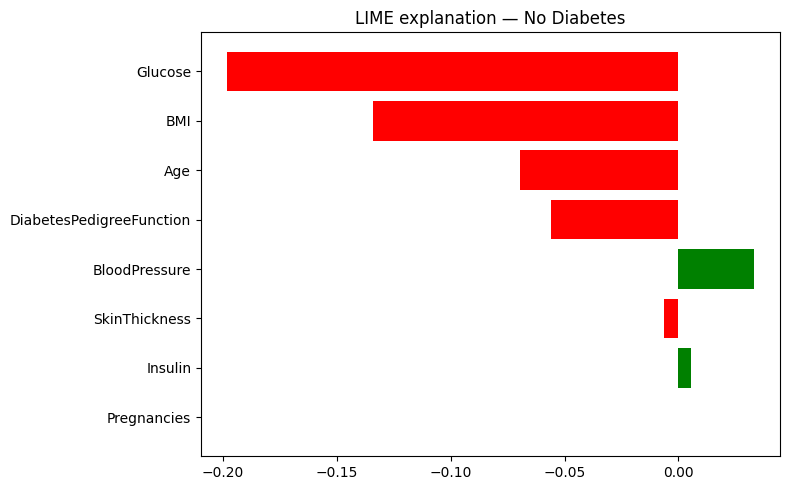

In [26]:
import matplotlib.pyplot as plt

exp_no_diab = lime_explainer.explain_instance(
    X_test_arr[no_diabetic_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_no_diab.as_pyplot_figure(label=0)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — No Diabetes")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/diabetes_lime_no_diabetes.png", dpi=150)
plt.show()


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


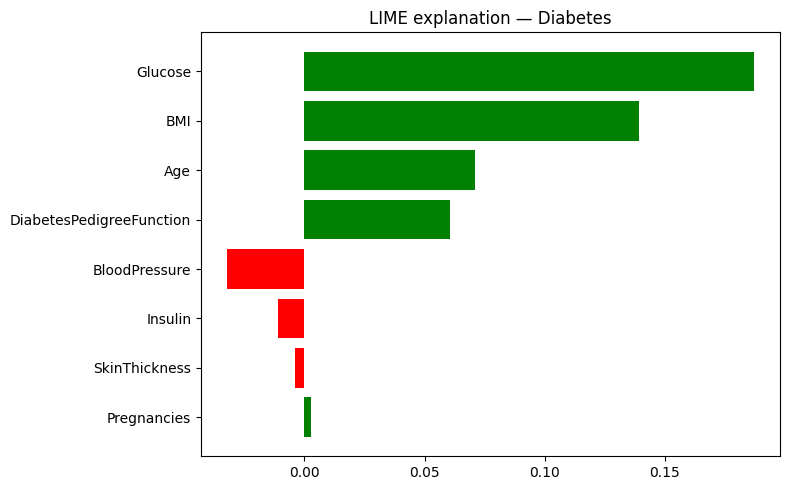

In [27]:
exp_diab = lime_explainer.explain_instance(
    X_test_arr[diabetic_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_diab.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — Diabetes")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/diabetes_lime_diabetes.png", dpi=150)
plt.show()


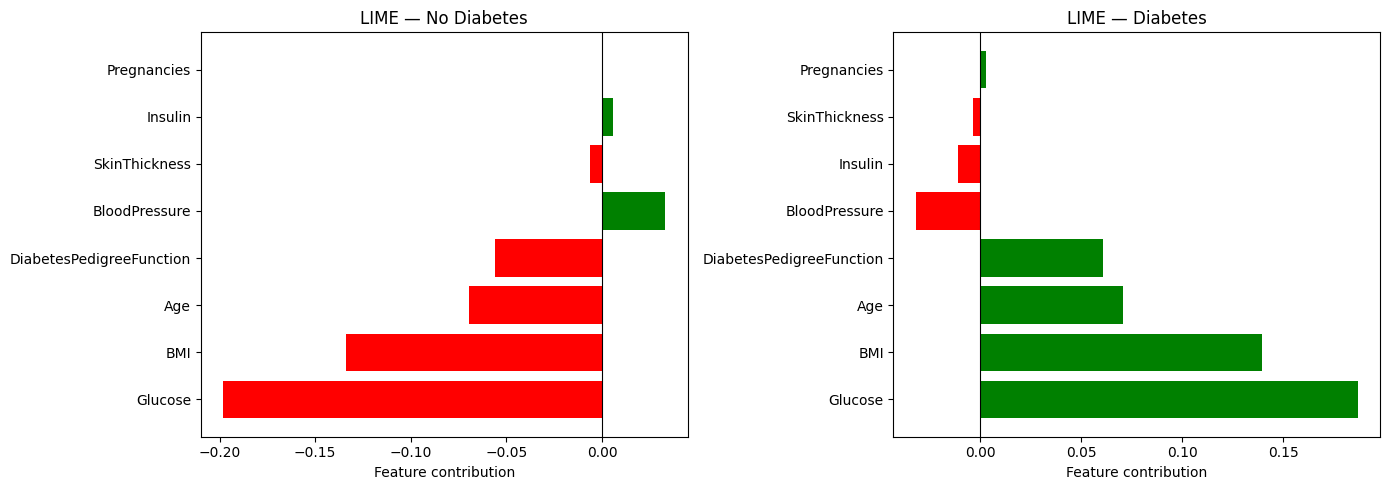

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp, label_idx, title in [
    (axes[0], exp_no_diab, 0, "No Diabetes"),
    (axes[1], exp_diab,    1, "Diabetes"),
]:
    vals = exp.as_list(label=label_idx)
    features_l, weights = zip(*vals)
    colors = ['green' if w > 0 else 'red' for w in weights]
    ax.barh(features_l, weights, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"LIME — {title}")
    ax.set_xlabel("Feature contribution")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/diabetes_lime_comparison.png", dpi=150)
plt.show()


#### Diabetes — LIME Global Ranking (multi-instance)


In [29]:
# ── LIME Global Ranking: aggregate over 50 test instances (Diabetes) ──
import re, numpy as np, pandas as pd, os

_OUTPUT_DIR_DIAB = 'outputs_diabetes'
_N_LIME = min(50, len(X_test_arr))

# feature_names_diab was set earlier (X_train.columns.tolist())
_feat_set_diab = set(feature_names_diab)

def _parse_lime_feature(condition_str, known_features):
    """Extract the base feature name from a LIME condition string."""
    # Try longest-match from known_features first
    for feat in sorted(known_features, key=len, reverse=True):
        if condition_str.startswith(feat):
            return feat
    # Fallback: split on comparison operators
    parts = re.split(r'[<>=!]', condition_str)
    return parts[0].strip()

_lime_global_diab = {}
for _i in range(_N_LIME):
    _exp = lime_explainer.explain_instance(
        X_test_arr[_i],
        model.predict_proba,
        num_features=len(feature_names_diab),
        labels=(0, 1)
    )
    for _cond, _w in _exp.as_list(label=1):
        _fname = _parse_lime_feature(str(_cond), _feat_set_diab)
        _lime_global_diab.setdefault(_fname, []).append(abs(_w))

_lime_ranking_diab = sorted(
    [(_f, sum(_ws) / len(_ws)) for _f, _ws in _lime_global_diab.items()],
    key=lambda x: -x[1]
)
_lime_df_diab = pd.DataFrame(_lime_ranking_diab, columns=['Feature', 'LIME_Score'])
_lime_df_diab['LIME_Rank'] = range(1, len(_lime_df_diab) + 1)
_lime_df_diab.to_csv(f'{_OUTPUT_DIR_DIAB}/lime_global_ranking.csv', index=False)
print(f'LIME Global Ranking (Diabetes, N={_N_LIME} instances):')
print(_lime_df_diab.to_string(index=False))
print(f'Saved: {_OUTPUT_DIR_DIAB}/lime_global_ranking.csv')


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warning

LIME Global Ranking (Diabetes, N=50 instances):
                 Feature  LIME_Score  LIME_Rank
                 Glucose    0.197000          1
                     BMI    0.131656          2
                     Age    0.073081          3
DiabetesPedigreeFunction    0.055020          4
           BloodPressure    0.031658          5
                 Insulin    0.006787          6
           SkinThickness    0.003480          7
             Pregnancies    0.002907          8
Saved: outputs_diabetes/lime_global_ranking.csv


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warning

Features: 8
Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5764 - auc: 0.3850 - loss: 0.7017 - val_accuracy: 0.6341 - val_auc: 0.5790 - val_loss: 0.6616
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6925 - auc: 0.6961 - loss: 0.6051 - val_accuracy: 0.6585 - val_auc: 0.7614 - val_loss: 0.5996
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7210 - auc: 0.7614 - loss: 0.5618 - val_accuracy: 0.6992 - val_auc: 0.8032 - val_loss: 0.5515
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7332 - auc: 0.7950 - loss: 0.5241 - val_accuracy: 0.7154 - val_auc: 0.8212 - val_loss: 0.5188
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7780 - auc: 0.8207 - loss: 0.4960 - val_accuracy: 0.7317 - val_auc: 0.8297 - val_loss: 0.4980
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7678 - auc: 0.8206 - loss: 0.4912 - val_accuracy: 0.7398 - val_auc: 0.8418 - val_loss: 0.4838
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0

100%|██████████| 154/154 [01:52<00:00,  1.37it/s]


SHAP values shape: (154, 8)


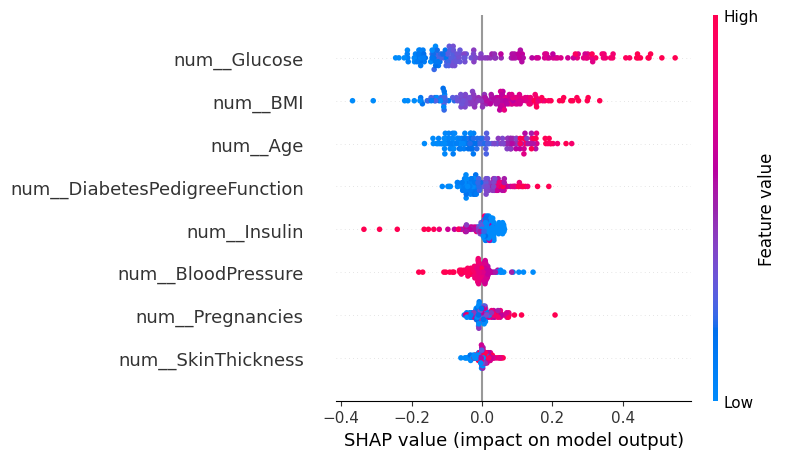

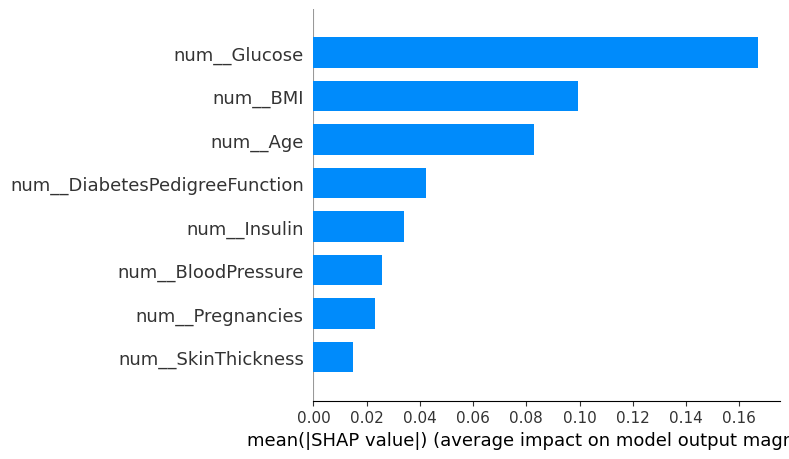

Saved: outputs_diabetes/diabetes_shap_summary.pdf/png and outputs_diabetes/diabetes_shap_bar.pdf/png


In [30]:
# =========================
# FULL PIPELINE — Diabetes (robust on older sklearn)
# - preprocess (handles bool/bool nullable + categoricals)
# - train Keras NN
# - compute SHAP (KernelExplainer)
# - export high-quality figures (PDF + PNG)
# =========================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap

OUTPUT_DIR = "outputs_diabetes"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------------------------
# 0) Assumes you already have:
# X_train, X_test, y_train, y_test
# -------------------------

# -------------------------
# 1) Coerce boolean-like columns to numeric
# -------------------------
X_train_ = X_train.copy()
X_test_  = X_test.copy()

bool_like_cols = X_train_.select_dtypes(include=["bool", "boolean"]).columns.tolist()
if bool_like_cols:
    X_train_[bool_like_cols] = X_train_[bool_like_cols].astype("float64")
    X_test_[bool_like_cols]  = X_test_[bool_like_cols].astype("float64")

# -------------------------
# 2) Identify numeric vs categorical columns AFTER coercion
# -------------------------
num_cols = X_train_.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_.select_dtypes(include=["object", "category"]).columns.tolist()

# -------------------------
# 3) Build preprocessing pipelines
# -------------------------
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

def _make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", _make_ohe()),
])

# IMPORTANT: only include transformers that actually have columns
transformers = []
if len(num_cols) > 0:
    transformers.append(("num", numeric_pipe, num_cols))
if len(cat_cols) > 0:
    transformers.append(("cat", categorical_pipe, cat_cols))

preprocess = ColumnTransformer(transformers=transformers, remainder="drop")

# -------------------------
# 4) Fit/transform preprocessing
# -------------------------
X_train_p = preprocess.fit_transform(X_train_)
X_test_p  = preprocess.transform(X_test_)

X_train_p = X_train_p.astype(np.float32)
X_test_p  = X_test_p.astype(np.float32)

# -------------------------
# 5) Robust feature names extraction (guards for empty categoricals)
# -------------------------
def get_feature_names_fitted(ct: ColumnTransformer, num_cols, cat_cols):
    # Newer sklearn: easiest
    if hasattr(ct, "get_feature_names_out"):
        return ct.get_feature_names_out().tolist()

    # Older sklearn: manual, but only if pieces exist
    names = []
    if len(num_cols) > 0:
        names.extend([str(c) for c in num_cols])

    if len(cat_cols) > 0:
        # Use fitted transformers_ (underscore!) which exists after fit
        # Find the fitted 'cat' transformer
        fitted_cat = None
        for name, trans, cols in ct.transformers_:
            if name == "cat":
                fitted_cat = trans
                break

        if fitted_cat is not None:
            # If pipeline, grab final OneHotEncoder
            ohe = fitted_cat.named_steps["onehot"] if hasattr(fitted_cat, "named_steps") else fitted_cat

            # Only call if actually fitted (has categories_)
            if hasattr(ohe, "categories_"):
                if hasattr(ohe, "get_feature_names_out"):
                    names.extend(ohe.get_feature_names_out(cat_cols).tolist())
                else:
                    names.extend(ohe.get_feature_names(cat_cols).tolist())

    return names

feature_names = get_feature_names_fitted(preprocess, num_cols, cat_cols)

# Sanity check
assert len(feature_names) == X_train_p.shape[1], (
    f"Feature name mismatch: {len(feature_names)} vs {X_train_p.shape[1]}"
)
print("Features:", len(feature_names))

# -------------------------
# 6) Train NN
# -------------------------
tf.random.set_seed(42)

model_keras = keras.Sequential([
    layers.Input(shape=(X_train_p.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
 )

history = model_keras.fit(
    X_train_p, y_train.to_numpy(),
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

print("Test metrics:", model_keras.evaluate(X_test_p, y_test.to_numpy(), verbose=0))

# -------------------------
# 7) SHAP (KernelExplainer)
# -------------------------
rng = np.random.default_rng(42)

bg_size = min(100, X_train_p.shape[0])
bg_idx = rng.choice(X_train_p.shape[0], size=bg_size, replace=False)
X_bg = X_train_p[bg_idx]

explain_size = min(200, X_test_p.shape[0])
X_explain = X_test_p[:explain_size]

def predict_proba(X):
    return model_keras.predict(X, verbose=0).reshape(-1)

explainer = shap.KernelExplainer(predict_proba, X_bg)
shap_values = explainer.shap_values(X_explain, nsamples=300)
shap_values = np.array(shap_values)

print("SHAP values shape:", shap_values.shape)

# -------------------------
# 8) Export high-quality plots
# -------------------------
# Beeswarm summary
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/diabetes_shap_summary.pdf", bbox_inches="tight")          # best for papers (vector)
plt.savefig(f"{OUTPUT_DIR}/diabetes_shap_summary.png", dpi=600, bbox_inches="tight") # best for slides/posters
plt.show()

# Bar summary
plt.figure(figsize=(6, 4))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/diabetes_shap_bar.pdf", bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/diabetes_shap_bar.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {OUTPUT_DIR}/diabetes_shap_summary.pdf/png and {OUTPUT_DIR}/diabetes_shap_bar.pdf/png")


In [31]:
# ── Save SHAP ranking to CSV (Diabetes) — with feature name normalization ──
import numpy as np, pandas as pd, os, re

_OUTPUT_DIR_DIAB = 'outputs_diabetes'
os.makedirs(_OUTPUT_DIR_DIAB, exist_ok=True)

# Original feature names for Diabetes (before ColumnTransformer encoding)
_orig_features_diab = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

def _normalize_shap_feature_name(name, original_features):
    """
    Strip ColumnTransformer prefixes (num__, cat__, remainder__) and
    match to the closest original feature name.
    Returns the original feature name if found, else the cleaned name.
    """
    # Strip known prefixes
    cleaned = re.sub(r'^(num__|cat__|remainder__)', '', name)
    # Try exact match first
    if cleaned in original_features:
        return cleaned
    # Try startswith match (e.g. 'thalach_binned' -> 'thalach')
    for feat in sorted(original_features, key=len, reverse=True):
        if cleaned.startswith(feat):
            return feat
    return cleaned  # fallback

def _aggregate_shap_by_feature(shap_vals, feature_names_raw, original_features):
    """
    Map SHAP values from encoded/prefixed names back to original features,
    aggregating with max |SHAP| per original feature.
    """
    feat_scores = {}
    mean_abs = np.abs(shap_vals).mean(axis=0)
    for raw_name, score in zip(feature_names_raw, mean_abs):
        orig = _normalize_shap_feature_name(raw_name, set(original_features))
        if orig not in feat_scores or score > feat_scores[orig]:
            feat_scores[orig] = score
    return sorted(feat_scores.items(), key=lambda x: -x[1])


_shap_vals_diab = np.array(shap_values)
_shap_ranking_diab = _aggregate_shap_by_feature(
    _shap_vals_diab, feature_names, _orig_features_diab
)
_shap_df_diab = pd.DataFrame(_shap_ranking_diab, columns=['Feature', 'SHAP_Score'])
_shap_df_diab['SHAP_Rank'] = range(1, len(_shap_df_diab) + 1)
_shap_df_diab.to_csv(f'{_OUTPUT_DIR_DIAB}/shap_ranking.csv', index=False)
print('SHAP Ranking (Diabetes) — normalized to original feature names:')
print(_shap_df_diab.to_string(index=False))
print(f'Saved: {_OUTPUT_DIR_DIAB}/shap_ranking.csv')


SHAP Ranking (Diabetes) — normalized to original feature names:
                 Feature  SHAP_Score  SHAP_Rank
                 Glucose    0.167010          1
                     BMI    0.099267          2
                     Age    0.082779          3
DiabetesPedigreeFunction    0.042435          4
                 Insulin    0.033864          5
           BloodPressure    0.025671          6
             Pregnancies    0.023016          7
           SkinThickness    0.014796          8
Saved: outputs_diabetes/shap_ranking.csv


### Heart Disease (UCI)


In [32]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# ==========================================
# DATA LOADING & PREP (UCI Heart Disease)
# ==========================================
# Fetch dataset (ID 45)
heart_disease = fetch_ucirepo(id=45)

# Extract features and targets
X = heart_disease.data.features
y = heart_disease.data.targets

# Combine into a single dataframe for the pipeline
df = pd.concat([X, y], axis=1)

# Target variable is 'num' (0 = no disease, 1-4 = has disease).
# Convert the 'num' variable directly to binary form (0 and 1) without changing its name.
df['num'] = (df['num'] > 0).astype(int)
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [33]:
features = ['sex', 'cp', 'trestbps', 'thalach', 'exang', 'oldpeak', 'ca', 'thal', 'age']
target = 'num'


In [34]:
df = df.dropna().reset_index(drop=True)
df.shape


(297, 14)

In [35]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [36]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [37]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Feature columns:", list(X.columns))


Accuracy: 0.75
Feature columns: ['sex', 'cp', 'trestbps', 'thalach', 'exang', 'oldpeak', 'ca', 'thal', 'age']


In [38]:
from sklearn.tree import export_graphviz
import graphviz
import shutil

OUTPUT_DIR = "outputs_heart_disease"
os.makedirs(OUTPUT_DIR, exist_ok=True)

dot = export_graphviz(
    model,
    out_file=None,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot)

if shutil.which("dot") is None:
    out_path = f"{OUTPUT_DIR}/heart_disease_tree.dot"
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(dot)
    print("Graphviz not found in PATH. Saved DOT instead:", out_path)
    print("To convert: dot -Tpng", out_path, "-o", f"{OUTPUT_DIR}/heart_disease_tree.png")
else:
    graph.render(f"{OUTPUT_DIR}/heart_disease_tree", format="png", cleanup=True)
    print(f"Saved: {OUTPUT_DIR}/heart_disease_tree.png")


Saved: outputs_heart_disease/heart_disease_tree.png


### Heart Disease — LIME Explanations


In [39]:
!pip install lime



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\hachimi\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [40]:
import lime
import lime.lime_tabular

# Heart Disease has mostly numeric features — no categorical dummies
cat_feature_idx = []

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    categorical_features=cat_feature_idx,
    mode='classification',
    random_state=42,
    discretize_continuous=False
)


In [41]:
test_labels = y_test.reset_index(drop=True)
X_test_arr = X_test.values
feature_names_hd = X_train.columns.tolist()

# Pick one disease and one no-disease instance from the test set
disease_idx    = test_labels[test_labels == 1].index[0]
no_disease_idx = test_labels[test_labels == 0].index[0]

print(f"Disease instance (test index {disease_idx}):")
print(dict(zip(feature_names_hd, X_test_arr[disease_idx])))
print(f"\nNo-disease instance (test index {no_disease_idx}):")
print(dict(zip(feature_names_hd, X_test_arr[no_disease_idx])))


Disease instance (test index 1):
{'sex': np.float64(1.0), 'cp': np.float64(4.0), 'trestbps': np.float64(112.0), 'thalach': np.float64(160.0), 'exang': np.float64(0.0), 'oldpeak': np.float64(0.0), 'ca': np.float64(1.0), 'thal': np.float64(3.0), 'age': np.float64(52.0)}

No-disease instance (test index 0):
{'sex': np.float64(0.0), 'cp': np.float64(2.0), 'trestbps': np.float64(112.0), 'thalach': np.float64(138.0), 'exang': np.float64(0.0), 'oldpeak': np.float64(0.0), 'ca': np.float64(0.0), 'thal': np.float64(3.0), 'age': np.float64(45.0)}


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


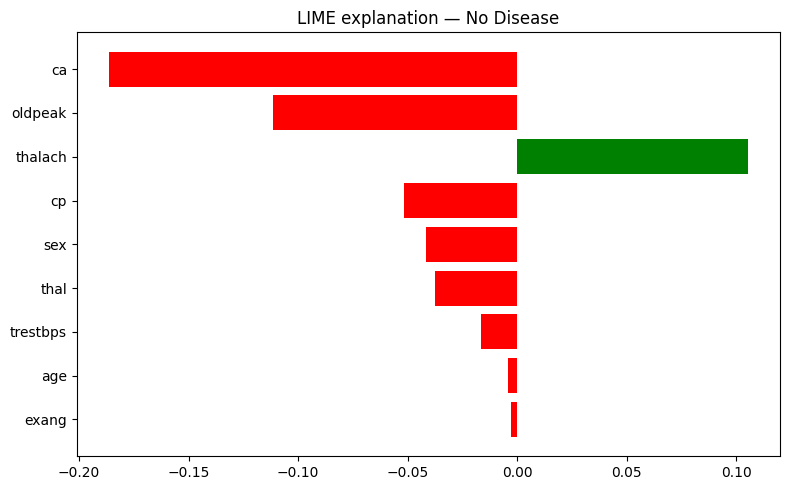

In [42]:
import matplotlib.pyplot as plt

exp_no_disease = lime_explainer.explain_instance(
    X_test_arr[no_disease_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_no_disease.as_pyplot_figure(label=0)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — No Disease")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heart_disease_lime_no_disease.png", dpi=150)
plt.show()


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


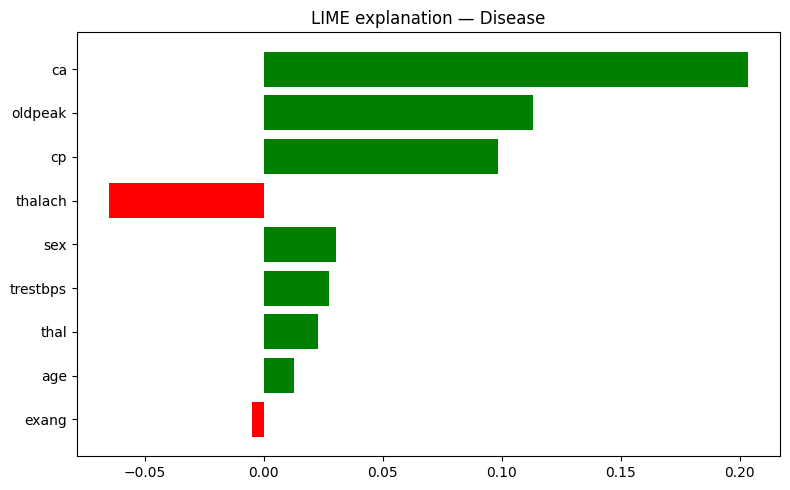

In [43]:
exp_disease = lime_explainer.explain_instance(
    X_test_arr[disease_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_disease.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — Disease")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heart_disease_lime_disease.png", dpi=150)
plt.show()


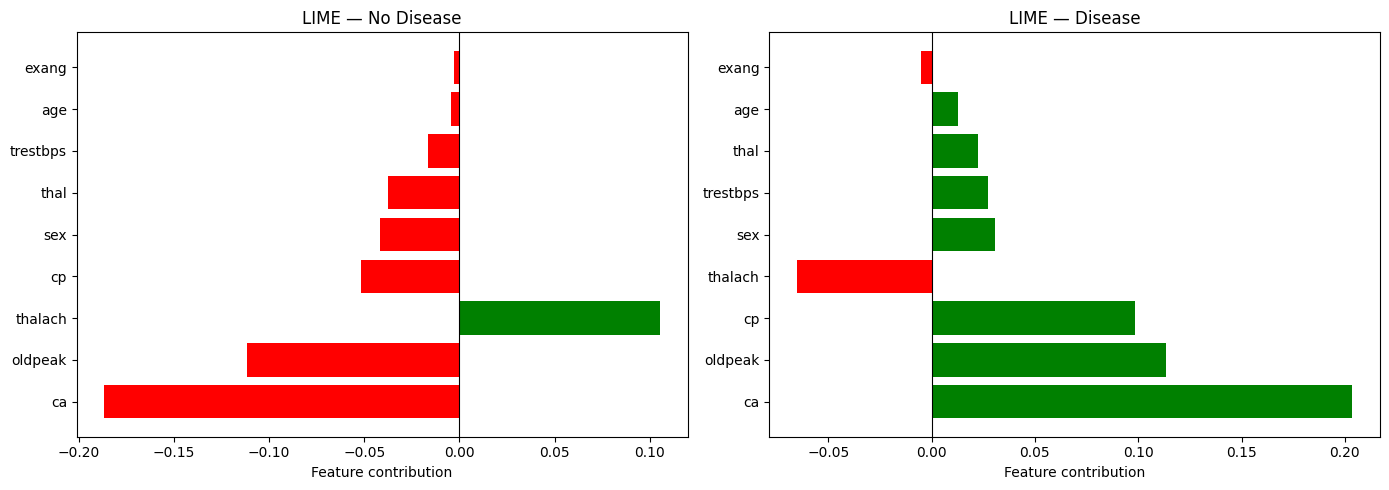

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp, label_idx, title in [
    (axes[0], exp_no_disease, 0, "No Disease"),
    (axes[1], exp_disease,    1, "Disease"),
]:
    vals = exp.as_list(label=label_idx)
    features_l, weights = zip(*vals)
    colors = ['green' if w > 0 else 'red' for w in weights]
    ax.barh(features_l, weights, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"LIME — {title}")
    ax.set_xlabel("Feature contribution")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heart_disease_lime_comparison.png", dpi=150)
plt.show()


#### Heart Disease — LIME Global Ranking (multi-instance)


In [45]:
# ── LIME Global Ranking: aggregate over 50 test instances (Heart Disease) ──
import re, numpy as np, pandas as pd, os
from sklearn.impute import SimpleImputer

_OUTPUT_DIR_HD = 'outputs_heart_disease'
_N_LIME_HD = min(50, len(X_test_arr))
_feat_set_hd = set(feature_names_hd)

# Impute NaN in X_test before passing to LIME (Heart Disease has missing values)
_imputer_hd = SimpleImputer(strategy='median')
_imputer_hd.fit(X_train)
_X_test_imputed_hd = _imputer_hd.transform(X_test_arr)

# Also re-fit LIME explainer with imputed training data
_X_train_imputed_hd = _imputer_hd.transform(X_train.values)
import lime.lime_tabular as _llt
_lime_explainer_hd = _llt.LimeTabularExplainer(
    training_data=_X_train_imputed_hd,
    feature_names=feature_names_hd,
    class_names=['No Disease', 'Disease'],
    categorical_features=[],
    mode='classification',
    random_state=42,
    discretize_continuous=False
)

def _parse_lime_feature(condition_str, known_features):
    """Extract the base feature name from a LIME condition string."""
    for feat in sorted(known_features, key=len, reverse=True):
        if condition_str.startswith(feat):
            return feat
    parts = re.split(r'[<>=!]', condition_str)
    return parts[0].strip()

_lime_global_hd = {}
for _i in range(_N_LIME_HD):
    _exp = _lime_explainer_hd.explain_instance(
        _X_test_imputed_hd[_i],
        model.predict_proba,
        num_features=len(feature_names_hd),
        labels=(0, 1)
    )
    for _cond, _w in _exp.as_list(label=1):
        _fname = _parse_lime_feature(str(_cond), _feat_set_hd)
        _lime_global_hd.setdefault(_fname, []).append(abs(_w))

_lime_ranking_hd = sorted(
    [(_f, sum(_ws) / len(_ws)) for _f, _ws in _lime_global_hd.items()],
    key=lambda x: -x[1]
)
_lime_df_hd = pd.DataFrame(_lime_ranking_hd, columns=['Feature', 'LIME_Score'])
_lime_df_hd['LIME_Rank'] = range(1, len(_lime_df_hd) + 1)
_lime_df_hd.to_csv(f'{_OUTPUT_DIR_HD}/lime_global_ranking.csv', index=False)
print(f'LIME Global Ranking (Heart Disease, N={_N_LIME_HD} instances):')
print(_lime_df_hd.to_string(index=False))
print(f'Saved: {_OUTPUT_DIR_HD}/lime_global_ranking.csv')


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\h

LIME Global Ranking (Heart Disease, N=50 instances):
 Feature  LIME_Score  LIME_Rank
      ca    0.189836          1
 oldpeak    0.108805          2
 thalach    0.095133          3
      cp    0.078576          4
     sex    0.042714          5
    thal    0.040657          6
trestbps    0.019001          7
     age    0.015071          8
   exang    0.004923          9
Saved: outputs_heart_disease/lime_global_ranking.csv


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warning


FULL PIPELINE — Heart Disease (robust on older sklearn)
- preprocess (handles bool/bool nullable + categoricals)
- train Keras NN
- compute SHAP (KernelExplainer)
- export high-quality figures (PDF + PNG)


Features: 9
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5291 - auc: 0.6857 - loss: 0.6894 - val_accuracy: 0.4583 - val_auc: 0.7812 - val_loss: 0.7127
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6085 - auc: 0.8000 - loss: 0.6268 - val_accuracy: 0.5208 - val_auc: 0.8008 - val_loss: 0.6546
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6561 - auc: 0.8238 - loss: 0.5897 - val_accuracy: 0.6667 - val_auc: 0.8057 - val_loss: 0.6113
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7566 - auc: 0.8853 - loss: 0.5321 - val_accuracy: 0.7500 - val_auc: 0.8174 - val_loss: 0.5767
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8095 - auc: 0.9118 - loss: 0.4967 - val_accuracy: 0.7917 - val_auc: 0.8252 - val_loss: 0.5501
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7989 - auc: 0.8988 - loss: 0.4795 - val_accuracy: 0.7917 - val_auc: 0.8281 - val_loss: 0.5281
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/st

100%|██████████| 60/60 [00:55<00:00,  1.09it/s]


SHAP values shape: (60, 9)


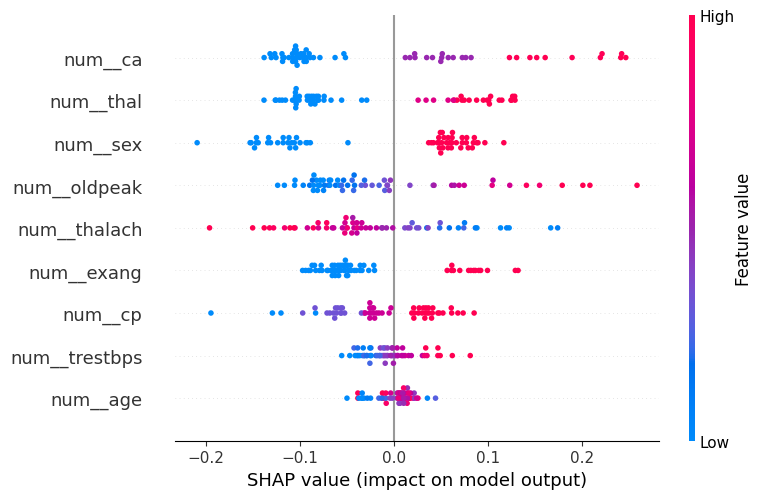

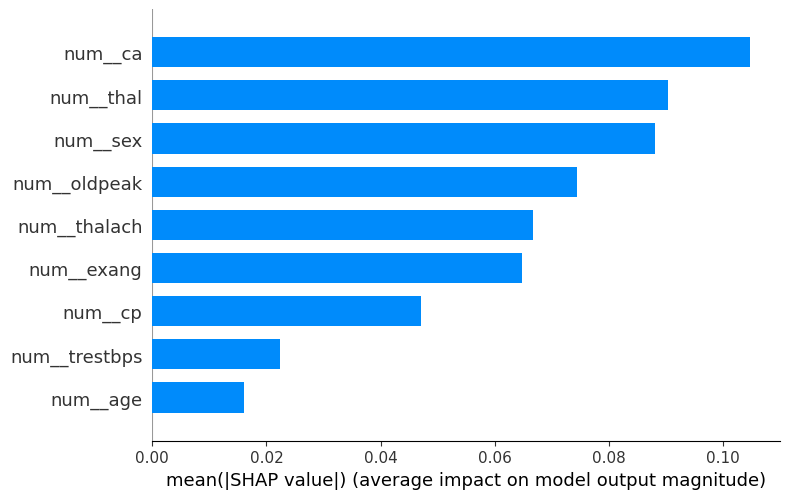

Saved: outputs_heart_disease/heart_disease_shap_summary.pdf/png and outputs_heart_disease/heart_disease_shap_bar.pdf/png


In [46]:

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap

OUTPUT_DIR = "outputs_heart_disease"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------------------------
# 0) Assumes you already have:
# X_train, X_test, y_train, y_test
# -------------------------

# -------------------------
# 1) Coerce boolean-like columns to numeric
# -------------------------
X_train_ = X_train.copy()
X_test_  = X_test.copy()

bool_like_cols = X_train_.select_dtypes(include=["bool", "boolean"]).columns.tolist()
if bool_like_cols:
    X_train_[bool_like_cols] = X_train_[bool_like_cols].astype("float64")
    X_test_[bool_like_cols]  = X_test_[bool_like_cols].astype("float64")

# -------------------------
# 2) Identify numeric vs categorical columns AFTER coercion
# -------------------------
num_cols = X_train_.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_.select_dtypes(include=["object", "category"]).columns.tolist()

# -------------------------
# 3) Build preprocessing pipelines
# -------------------------
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

def _make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", _make_ohe()),
])

# IMPORTANT: only include transformers that actually have columns
transformers = []
if len(num_cols) > 0:
    transformers.append(("num", numeric_pipe, num_cols))
if len(cat_cols) > 0:
    transformers.append(("cat", categorical_pipe, cat_cols))

preprocess = ColumnTransformer(transformers=transformers, remainder="drop")

# -------------------------
# 4) Fit/transform preprocessing
# -------------------------
X_train_p = preprocess.fit_transform(X_train_)
X_test_p  = preprocess.transform(X_test_)

X_train_p = X_train_p.astype(np.float32)
X_test_p  = X_test_p.astype(np.float32)

# -------------------------
# 5) Robust feature names extraction (guards for empty categoricals)
# -------------------------
def get_feature_names_fitted(ct: ColumnTransformer, num_cols, cat_cols):
    # Newer sklearn: easiest
    if hasattr(ct, "get_feature_names_out"):
        return ct.get_feature_names_out().tolist()

    # Older sklearn: manual, but only if pieces exist
    names = []
    if len(num_cols) > 0:
        names.extend([str(c) for c in num_cols])

    if len(cat_cols) > 0:
        # Use fitted transformers_ (underscore!) which exists after fit
        # Find the fitted 'cat' transformer
        fitted_cat = None
        for name, trans, cols in ct.transformers_:
            if name == "cat":
                fitted_cat = trans
                break

        if fitted_cat is not None:
            # If pipeline, grab final OneHotEncoder
            ohe = fitted_cat.named_steps["onehot"] if hasattr(fitted_cat, "named_steps") else fitted_cat

            # Only call if actually fitted (has categories_)
            if hasattr(ohe, "categories_"):
                if hasattr(ohe, "get_feature_names_out"):
                    names.extend(ohe.get_feature_names_out(cat_cols).tolist())
                else:
                    names.extend(ohe.get_feature_names(cat_cols).tolist())

    return names

feature_names = get_feature_names_fitted(preprocess, num_cols, cat_cols)

# Sanity check
assert len(feature_names) == X_train_p.shape[1], (
    f"Feature name mismatch: {len(feature_names)} vs {X_train_p.shape[1]}"
)
print("Features:", len(feature_names))

# -------------------------
# 6) Train NN
# -------------------------
tf.random.set_seed(42)

model_keras = keras.Sequential([
    layers.Input(shape=(X_train_p.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
 )

history = model_keras.fit(
    X_train_p, y_train.to_numpy(),
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

print("Test metrics:", model_keras.evaluate(X_test_p, y_test.to_numpy(), verbose=0))

# -------------------------
# 7) SHAP (KernelExplainer)
# -------------------------
rng = np.random.default_rng(42)

bg_size = min(100, X_train_p.shape[0])
bg_idx = rng.choice(X_train_p.shape[0], size=bg_size, replace=False)
X_bg = X_train_p[bg_idx]

explain_size = min(200, X_test_p.shape[0])
X_explain = X_test_p[:explain_size]

def predict_proba(X):
    return model_keras.predict(X, verbose=0).reshape(-1)

explainer = shap.KernelExplainer(predict_proba, X_bg)
shap_values = explainer.shap_values(X_explain, nsamples=300)
shap_values = np.array(shap_values)

print("SHAP values shape:", shap_values.shape)

# -------------------------
# 8) Export high-quality plots
# -------------------------
# Beeswarm summary
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heart_disease_shap_summary.pdf", bbox_inches="tight")          # best for papers (vector)
plt.savefig(f"{OUTPUT_DIR}/heart_disease_shap_summary.png", dpi=600, bbox_inches="tight") # best for slides/posters
plt.show()

# Bar summary
plt.figure(figsize=(6, 4))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heart_disease_shap_bar.pdf", bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/heart_disease_shap_bar.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {OUTPUT_DIR}/heart_disease_shap_summary.pdf/png and {OUTPUT_DIR}/heart_disease_shap_bar.pdf/png")


In [47]:
# ── Save SHAP ranking to CSV (Heart Disease) — with feature name normalization ──
import numpy as np, pandas as pd, os, re

_OUTPUT_DIR_HD = 'outputs_heart_disease'
os.makedirs(_OUTPUT_DIR_HD, exist_ok=True)

# Original feature names for Heart Disease
_orig_features_hd = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'
]

def _normalize_shap_feature_name(name, original_features):
    """
    Strip ColumnTransformer prefixes (num__, cat__, remainder__) and
    match to the closest original feature name.
    Returns the original feature name if found, else the cleaned name.
    """
    # Strip known prefixes
    cleaned = re.sub(r'^(num__|cat__|remainder__)', '', name)
    # Try exact match first
    if cleaned in original_features:
        return cleaned
    # Try startswith match (e.g. 'thalach_binned' -> 'thalach')
    for feat in sorted(original_features, key=len, reverse=True):
        if cleaned.startswith(feat):
            return feat
    return cleaned  # fallback

def _aggregate_shap_by_feature(shap_vals, feature_names_raw, original_features):
    """
    Map SHAP values from encoded/prefixed names back to original features,
    aggregating with max |SHAP| per original feature.
    """
    feat_scores = {}
    mean_abs = np.abs(shap_vals).mean(axis=0)
    for raw_name, score in zip(feature_names_raw, mean_abs):
        orig = _normalize_shap_feature_name(raw_name, set(original_features))
        if orig not in feat_scores or score > feat_scores[orig]:
            feat_scores[orig] = score
    return sorted(feat_scores.items(), key=lambda x: -x[1])


_shap_vals_hd = np.array(shap_values)
_shap_ranking_hd = _aggregate_shap_by_feature(
    _shap_vals_hd, feature_names, _orig_features_hd
)
_shap_df_hd = pd.DataFrame(_shap_ranking_hd, columns=['Feature', 'SHAP_Score'])
_shap_df_hd['SHAP_Rank'] = range(1, len(_shap_df_hd) + 1)
_shap_df_hd.to_csv(f'{_OUTPUT_DIR_HD}/shap_ranking.csv', index=False)
print('SHAP Ranking (Heart Disease) — normalized to original feature names:')
print(_shap_df_hd.to_string(index=False))
print(f'Saved: {_OUTPUT_DIR_HD}/shap_ranking.csv')


SHAP Ranking (Heart Disease) — normalized to original feature names:
 Feature  SHAP_Score  SHAP_Rank
      ca    0.104739          1
    thal    0.090375          2
     sex    0.088038          3
 oldpeak    0.074460          4
 thalach    0.066715          5
   exang    0.064716          6
      cp    0.047044          7
trestbps    0.022448          8
     age    0.016044          9
Saved: outputs_heart_disease/shap_ranking.csv


### Breast Cancer (UCI)

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# ==========================================
# DATA LOADING & PREP (UCI Breast Cancer)
# ==========================================
# Fetch dataset
dataset = fetch_ucirepo(id=17)

# Extract features and targets
X = dataset.data.features
y = dataset.data.targets

# Combine into a single dataframe for the pipeline
df = pd.concat([X, y], axis=1)

df['Diagnosis'] = (df['Diagnosis'] == 'M').astype(int)
df.head()

In [ ]:
features = ['concave_points3', 'concave_points1', 'perimeter3', 'area3', 'radius3', 'perimeter1', 'concavity1', 'area1', 'radius1']
target = 'Diagnosis'

In [ ]:
df = df.dropna().reset_index(drop=True)
df.shape

In [ ]:
import scipy.stats as stats
from sklearn.ensemble import RandomForestClassifier

X_clean = df[features].copy()
y_clean = df['Diagnosis']

cat_cols_filter = [c for c in features if df[c].dtype == 'object']
if cat_cols_filter:
    from sklearn.preprocessing import OrdinalEncoder
    enc_f = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_clean[cat_cols_filter] = enc_f.fit_transform(X_clean[cat_cols_filter].astype(str))

print("Evaluate Features using P-value:")
p_values = {}
for col in X_clean.columns:
    try:
        group0 = X_clean[y_clean == 0][col]
        group1 = X_clean[y_clean == 1][col]
        if len(group0) > 0 and len(group1) > 0:
            t_stat, p = stats.ttest_ind(group0, group1)
            p_values[col] = p
    except:
        pass

p_df = pd.DataFrame(list(p_values.items()), columns=['Feature', 'P-Value']).sort_values('P-Value')
print(p_df)

print("\nEvaluate Features using Random Forest:")
rf_eval = RandomForestClassifier(n_estimators=100, random_state=42)
rf_eval.fit(X_clean, y_clean)

importances = pd.DataFrame({
    'Feature': X_clean.columns,
    'Importance': rf_eval.feature_importances_
}).sort_values('Importance', ascending=False)
print(importances)

In [ ]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Ordinal encode for basic DT if there are categorical columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    from sklearn.preprocessing import OrdinalEncoder
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train[cat_cols] = enc.fit_transform(X_train[cat_cols].astype(str))
    X_test[cat_cols] = enc.transform(X_test[cat_cols].astype(str))

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Feature columns:", list(X.columns))

In [ ]:
from sklearn.tree import export_graphviz
import graphviz
import shutil
import os

OUTPUT_DIR = "outputs_breast_cancer"
os.makedirs(OUTPUT_DIR, exist_ok=True)

dot = export_graphviz(
    model,
    out_file=None,
    feature_names=X.columns,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot)

if shutil.which("dot") is None:
    out_path = f"{OUTPUT_DIR}/breast_cancer_tree.dot"
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(dot)
    print("Graphviz not found in PATH. Saved DOT instead:", out_path)
    print("To convert: dot -Tpng", out_path, "-o", f"{OUTPUT_DIR}/breast_cancer_tree.png")
else:
    graph.render(f"{OUTPUT_DIR}/breast_cancer_tree", format="png", cleanup=True)
    print(f"Saved: {OUTPUT_DIR}/breast_cancer_tree.png")

### Breast Cancer — LIME Explanations

In [ ]:
!pip install lime

In [ ]:
import lime
import lime.lime_tabular

cat_feature_idx = [X_train.columns.get_loc(c) for c in []]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Benign', 'Malignant'],
    categorical_features=cat_feature_idx,
    mode='classification',
    random_state=42,
    discretize_continuous=False
)

In [ ]:
test_labels = y_test.reset_index(drop=True)
X_test_arr = X_test.values
feature_names_slug = X_train.columns.tolist()

disease_idx    = test_labels[test_labels == 1].index[0]
no_disease_idx = test_labels[test_labels == 0].index[0]

print(f"Positive instance (test index {disease_idx}):")
print(dict(zip(feature_names_slug, X_test_arr[disease_idx])))
print(f"\nNegative instance (test index {no_disease_idx}):")
print(dict(zip(feature_names_slug, X_test_arr[no_disease_idx])))

In [ ]:
import matplotlib.pyplot as plt

exp_no_disease = lime_explainer.explain_instance(
    X_test_arr[no_disease_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_no_disease.as_pyplot_figure(label=0)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — Benign")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/breast_cancer_lime_negative.png", dpi=150)
plt.show()

In [ ]:
exp_disease = lime_explainer.explain_instance(
    X_test_arr[disease_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_disease.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — Malignant")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/breast_cancer_lime_positive.png", dpi=150)
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp, label_idx, title in [
    (axes[0], exp_no_disease, 0, "Benign"),
    (axes[1], exp_disease,    1, "Malignant"),
]:
    vals = exp.as_list(label=label_idx)
    features_l, weights = zip(*vals)
    colors = ['green' if w > 0 else 'red' for w in weights]
    ax.barh(features_l, weights, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"LIME — {title}")
    ax.set_xlabel("Feature contribution")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/breast_cancer_lime_comparison.png", dpi=150)
plt.show()

#### Breast Cancer — LIME Global Ranking (multi-instance)

In [ ]:
import re, numpy as np, pandas as pd, os
from sklearn.impute import SimpleImputer

_OUTPUT_DIR = 'outputs_breast_cancer'
_N_LIME = min(50, len(X_test_arr))
_feat_set = set(feature_names_slug)

# Impute NaN in X_test before passing to LIME
_imputer = SimpleImputer(strategy='median')
_imputer.fit(X_train)
_X_test_imputed = _imputer.transform(X_test_arr)

_X_train_imputed = _imputer.transform(X_train.values)
import lime.lime_tabular as _llt
_lime_explainer = _llt.LimeTabularExplainer(
    training_data=_X_train_imputed,
    feature_names=feature_names_slug,
    class_names=['Benign', 'Malignant'],
    categorical_features=cat_feature_idx,
    mode='classification',
    random_state=42,
    discretize_continuous=False
)

def _parse_lime_feature(condition_str, known_features):
    for feat in sorted(known_features, key=len, reverse=True):
        if condition_str.startswith(feat):
            return feat
    parts = re.split(r'[<>=!]', condition_str)
    return parts[0].strip()

_lime_global = {}
for _i in range(_N_LIME):
    _exp = _lime_explainer.explain_instance(
        _X_test_imputed[_i],
        model.predict_proba,
        num_features=len(feature_names_slug),
        labels=(0, 1)
    )
    for _cond, _w in _exp.as_list(label=1):
        _fname = _parse_lime_feature(str(_cond), _feat_set)
        _lime_global.setdefault(_fname, []).append(abs(_w))

_lime_ranking = sorted(
    [(_f, sum(_ws) / len(_ws)) for _f, _ws in _lime_global.items()],
    key=lambda x: -x[1]
)
_lime_df = pd.DataFrame(_lime_ranking, columns=['Feature', 'LIME_Score'])
_lime_df['LIME_Rank'] = range(1, len(_lime_df) + 1)
_lime_df.to_csv(f'{_OUTPUT_DIR}/lime_global_ranking.csv', index=False)
print(f'LIME Global Ranking (Breast Cancer, N={_N_LIME} instances):')
print(_lime_df.to_string(index=False))
print(f'Saved: {_OUTPUT_DIR}/lime_global_ranking.csv')

#### FULL PIPELINE — Breast Cancer

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import shap

OUTPUT_DIR = "outputs_breast_cancer"
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_train_ = X_train.copy()
X_test_  = X_test.copy()

bool_like_cols = X_train_.select_dtypes(include=["bool", "boolean"]).columns.tolist()
if bool_like_cols:
    X_train_[bool_like_cols] = X_train_[bool_like_cols].astype("float64")
    X_test_[bool_like_cols]  = X_test_[bool_like_cols].astype("float64")

num_cols = X_train_.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

def _make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", _make_ohe()),
])

transformers = []
if len(num_cols) > 0:
    transformers.append(("num", numeric_pipe, num_cols))
if len(cat_cols) > 0:
    transformers.append(("cat", categorical_pipe, cat_cols))

preprocess = ColumnTransformer(transformers=transformers, remainder="drop")

X_train_p = preprocess.fit_transform(X_train_)
X_test_p  = preprocess.transform(X_test_)

X_train_p = X_train_p.astype(np.float32)
X_test_p  = X_test_p.astype(np.float32)

def get_feature_names_fitted(ct: ColumnTransformer, num_cols, cat_cols):
    if hasattr(ct, "get_feature_names_out"):
        return ct.get_feature_names_out().tolist()
    names = []
    if len(num_cols) > 0:
        names.extend([str(c) for c in num_cols])
    if len(cat_cols) > 0:
        fitted_cat = None
        for name, trans, cols in ct.transformers_:
            if name == "cat":
                fitted_cat = trans
                break
        if fitted_cat is not None:
            ohe = fitted_cat.named_steps["onehot"] if hasattr(fitted_cat, "named_steps") else fitted_cat
            if hasattr(ohe, "categories_"):
                if hasattr(ohe, "get_feature_names_out"):
                    names.extend(ohe.get_feature_names_out(cat_cols).tolist())
                else:
                    names.extend(ohe.get_feature_names(cat_cols).tolist())
    return names

feature_names_out = get_feature_names_fitted(preprocess, num_cols, cat_cols)
print("Features:", len(feature_names_out))

tf.random.set_seed(42)

model_keras = keras.Sequential([
    layers.Input(shape=(X_train_p.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

history = model_keras.fit(
    X_train_p, y_train.to_numpy(),
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

print("Test metrics:", model_keras.evaluate(X_test_p, y_test.to_numpy(), verbose=0))

rng = np.random.default_rng(42)

bg_size = min(100, X_train_p.shape[0])
bg_idx = rng.choice(X_train_p.shape[0], size=bg_size, replace=False)
X_bg = X_train_p[bg_idx]

explain_size = min(200, X_test_p.shape[0])
X_explain = X_test_p[:explain_size]

def predict_proba(X):
    return model_keras.predict(X, verbose=0).reshape(-1)

explainer = shap.KernelExplainer(predict_proba, X_bg)
shap_values = explainer.shap_values(X_explain, nsamples=300)
shap_values = np.array(shap_values)

print("SHAP values shape:", shap_values.shape)

plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names_out,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/breast_cancer_shap_summary.pdf", bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/breast_cancer_shap_summary.png", dpi=600, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names_out,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/breast_cancer_shap_bar.pdf", bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/breast_cancer_shap_bar.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {OUTPUT_DIR}/breast_cancer_shap_summary.pdf/png and {OUTPUT_DIR}/breast_cancer_shap_bar.pdf/png")

In [ ]:
import numpy as np, pandas as pd, os, re

_OUTPUT_DIR = 'outputs_breast_cancer'
os.makedirs(_OUTPUT_DIR, exist_ok=True)

_orig_features = ['concave_points3', 'concave_points1', 'perimeter3', 'area3', 'radius3', 'perimeter1', 'concavity1', 'area1', 'radius1']

def _normalize_shap_feature_name(name, original_features):
    cleaned = re.sub(r'^(num__|cat__|remainder__)', '', name)
    if cleaned in original_features:
        return cleaned
    for feat in sorted(original_features, key=len, reverse=True):
        if cleaned.startswith(feat):
            return feat
    return cleaned

def _aggregate_shap_by_feature(shap_vals, feature_names_raw, original_features):
    feat_scores = {}
    mean_abs = np.abs(shap_vals).mean(axis=0)
    for raw_name, score in zip(feature_names_raw, mean_abs):
        orig = _normalize_shap_feature_name(raw_name, set(original_features))
        if orig not in feat_scores or score > feat_scores[orig]:
            feat_scores[orig] = score
    return sorted(feat_scores.items(), key=lambda x: -x[1])

_shap_vals = np.array(shap_values)
_shap_ranking = _aggregate_shap_by_feature(
    _shap_vals, feature_names_out, _orig_features
)
_shap_df = pd.DataFrame(_shap_ranking, columns=['Feature', 'SHAP_Score'])
_shap_df['SHAP_Rank'] = range(1, len(_shap_df) + 1)
_shap_df.to_csv(f'{_OUTPUT_DIR}/shap_ranking.csv', index=False)
print('SHAP Ranking (Breast Cancer) — normalized to original feature names:')
print(_shap_df.to_string(index=False))
print(f'Saved: {_OUTPUT_DIR}/shap_ranking.csv')

### Maternal Health Risk (UCI)

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# ==========================================
# DATA LOADING & PREP (UCI Maternal Health Risk)
# ==========================================
# Fetch dataset
dataset = fetch_ucirepo(id=863)

# Extract features and targets
X = dataset.data.features
y = dataset.data.targets

# Combine into a single dataframe for the pipeline
df = pd.concat([X, y], axis=1)

df['RiskLevel'] = df['RiskLevel'].apply(lambda x: 1 if str(x).lower().strip() == 'high risk' else 0)
df.head()

In [ ]:
features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
target = 'RiskLevel'

In [ ]:
df = df.dropna().reset_index(drop=True)
df.shape

In [ ]:
import scipy.stats as stats
from sklearn.ensemble import RandomForestClassifier

X_clean = df[features].copy()
y_clean = df['RiskLevel']

cat_cols_filter = [c for c in features if df[c].dtype == 'object']
if cat_cols_filter:
    from sklearn.preprocessing import OrdinalEncoder
    enc_f = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_clean[cat_cols_filter] = enc_f.fit_transform(X_clean[cat_cols_filter].astype(str))

print("Evaluate Features using P-value:")
p_values = {}
for col in X_clean.columns:
    try:
        group0 = X_clean[y_clean == 0][col]
        group1 = X_clean[y_clean == 1][col]
        if len(group0) > 0 and len(group1) > 0:
            t_stat, p = stats.ttest_ind(group0, group1)
            p_values[col] = p
    except:
        pass

p_df = pd.DataFrame(list(p_values.items()), columns=['Feature', 'P-Value']).sort_values('P-Value')
print(p_df)

print("\nEvaluate Features using Random Forest:")
rf_eval = RandomForestClassifier(n_estimators=100, random_state=42)
rf_eval.fit(X_clean, y_clean)

importances = pd.DataFrame({
    'Feature': X_clean.columns,
    'Importance': rf_eval.feature_importances_
}).sort_values('Importance', ascending=False)
print(importances)

In [ ]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Ordinal encode for basic DT if there are categorical columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    from sklearn.preprocessing import OrdinalEncoder
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train[cat_cols] = enc.fit_transform(X_train[cat_cols].astype(str))
    X_test[cat_cols] = enc.transform(X_test[cat_cols].astype(str))

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Feature columns:", list(X.columns))

In [ ]:
from sklearn.tree import export_graphviz
import graphviz
import shutil
import os

OUTPUT_DIR = "outputs_maternal_health_risk"
os.makedirs(OUTPUT_DIR, exist_ok=True)

dot = export_graphviz(
    model,
    out_file=None,
    feature_names=X.columns,
    class_names=["Low/Mid Risk", "High Risk"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot)

if shutil.which("dot") is None:
    out_path = f"{OUTPUT_DIR}/maternal_health_risk_tree.dot"
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(dot)
    print("Graphviz not found in PATH. Saved DOT instead:", out_path)
    print("To convert: dot -Tpng", out_path, "-o", f"{OUTPUT_DIR}/maternal_health_risk_tree.png")
else:
    graph.render(f"{OUTPUT_DIR}/maternal_health_risk_tree", format="png", cleanup=True)
    print(f"Saved: {OUTPUT_DIR}/maternal_health_risk_tree.png")

### Maternal Health Risk — LIME Explanations

In [ ]:
!pip install lime

In [ ]:
import lime
import lime.lime_tabular

cat_feature_idx = [X_train.columns.get_loc(c) for c in []]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Low/Mid Risk', 'High Risk'],
    categorical_features=cat_feature_idx,
    mode='classification',
    random_state=42,
    discretize_continuous=False
)

In [ ]:
test_labels = y_test.reset_index(drop=True)
X_test_arr = X_test.values
feature_names_slug = X_train.columns.tolist()

disease_idx    = test_labels[test_labels == 1].index[0]
no_disease_idx = test_labels[test_labels == 0].index[0]

print(f"Positive instance (test index {disease_idx}):")
print(dict(zip(feature_names_slug, X_test_arr[disease_idx])))
print(f"\nNegative instance (test index {no_disease_idx}):")
print(dict(zip(feature_names_slug, X_test_arr[no_disease_idx])))

In [ ]:
import matplotlib.pyplot as plt

exp_no_disease = lime_explainer.explain_instance(
    X_test_arr[no_disease_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_no_disease.as_pyplot_figure(label=0)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — Low/Mid Risk")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/maternal_health_risk_lime_negative.png", dpi=150)
plt.show()

In [ ]:
exp_disease = lime_explainer.explain_instance(
    X_test_arr[disease_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_disease.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — High Risk")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/maternal_health_risk_lime_positive.png", dpi=150)
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp, label_idx, title in [
    (axes[0], exp_no_disease, 0, "Low/Mid Risk"),
    (axes[1], exp_disease,    1, "High Risk"),
]:
    vals = exp.as_list(label=label_idx)
    features_l, weights = zip(*vals)
    colors = ['green' if w > 0 else 'red' for w in weights]
    ax.barh(features_l, weights, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"LIME — {title}")
    ax.set_xlabel("Feature contribution")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/maternal_health_risk_lime_comparison.png", dpi=150)
plt.show()

#### Maternal Health Risk — LIME Global Ranking (multi-instance)

In [ ]:
import re, numpy as np, pandas as pd, os
from sklearn.impute import SimpleImputer

_OUTPUT_DIR = 'outputs_maternal_health_risk'
_N_LIME = min(50, len(X_test_arr))
_feat_set = set(feature_names_slug)

# Impute NaN in X_test before passing to LIME
_imputer = SimpleImputer(strategy='median')
_imputer.fit(X_train)
_X_test_imputed = _imputer.transform(X_test_arr)

_X_train_imputed = _imputer.transform(X_train.values)
import lime.lime_tabular as _llt
_lime_explainer = _llt.LimeTabularExplainer(
    training_data=_X_train_imputed,
    feature_names=feature_names_slug,
    class_names=['Low/Mid Risk', 'High Risk'],
    categorical_features=cat_feature_idx,
    mode='classification',
    random_state=42,
    discretize_continuous=False
)

def _parse_lime_feature(condition_str, known_features):
    for feat in sorted(known_features, key=len, reverse=True):
        if condition_str.startswith(feat):
            return feat
    parts = re.split(r'[<>=!]', condition_str)
    return parts[0].strip()

_lime_global = {}
for _i in range(_N_LIME):
    _exp = _lime_explainer.explain_instance(
        _X_test_imputed[_i],
        model.predict_proba,
        num_features=len(feature_names_slug),
        labels=(0, 1)
    )
    for _cond, _w in _exp.as_list(label=1):
        _fname = _parse_lime_feature(str(_cond), _feat_set)
        _lime_global.setdefault(_fname, []).append(abs(_w))

_lime_ranking = sorted(
    [(_f, sum(_ws) / len(_ws)) for _f, _ws in _lime_global.items()],
    key=lambda x: -x[1]
)
_lime_df = pd.DataFrame(_lime_ranking, columns=['Feature', 'LIME_Score'])
_lime_df['LIME_Rank'] = range(1, len(_lime_df) + 1)
_lime_df.to_csv(f'{_OUTPUT_DIR}/lime_global_ranking.csv', index=False)
print(f'LIME Global Ranking (Maternal Health Risk, N={_N_LIME} instances):')
print(_lime_df.to_string(index=False))
print(f'Saved: {_OUTPUT_DIR}/lime_global_ranking.csv')

#### FULL PIPELINE — Maternal Health Risk

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import shap

OUTPUT_DIR = "outputs_maternal_health_risk"
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_train_ = X_train.copy()
X_test_  = X_test.copy()

bool_like_cols = X_train_.select_dtypes(include=["bool", "boolean"]).columns.tolist()
if bool_like_cols:
    X_train_[bool_like_cols] = X_train_[bool_like_cols].astype("float64")
    X_test_[bool_like_cols]  = X_test_[bool_like_cols].astype("float64")

num_cols = X_train_.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

def _make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", _make_ohe()),
])

transformers = []
if len(num_cols) > 0:
    transformers.append(("num", numeric_pipe, num_cols))
if len(cat_cols) > 0:
    transformers.append(("cat", categorical_pipe, cat_cols))

preprocess = ColumnTransformer(transformers=transformers, remainder="drop")

X_train_p = preprocess.fit_transform(X_train_)
X_test_p  = preprocess.transform(X_test_)

X_train_p = X_train_p.astype(np.float32)
X_test_p  = X_test_p.astype(np.float32)

def get_feature_names_fitted(ct: ColumnTransformer, num_cols, cat_cols):
    if hasattr(ct, "get_feature_names_out"):
        return ct.get_feature_names_out().tolist()
    names = []
    if len(num_cols) > 0:
        names.extend([str(c) for c in num_cols])
    if len(cat_cols) > 0:
        fitted_cat = None
        for name, trans, cols in ct.transformers_:
            if name == "cat":
                fitted_cat = trans
                break
        if fitted_cat is not None:
            ohe = fitted_cat.named_steps["onehot"] if hasattr(fitted_cat, "named_steps") else fitted_cat
            if hasattr(ohe, "categories_"):
                if hasattr(ohe, "get_feature_names_out"):
                    names.extend(ohe.get_feature_names_out(cat_cols).tolist())
                else:
                    names.extend(ohe.get_feature_names(cat_cols).tolist())
    return names

feature_names_out = get_feature_names_fitted(preprocess, num_cols, cat_cols)
print("Features:", len(feature_names_out))

tf.random.set_seed(42)

model_keras = keras.Sequential([
    layers.Input(shape=(X_train_p.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

history = model_keras.fit(
    X_train_p, y_train.to_numpy(),
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

print("Test metrics:", model_keras.evaluate(X_test_p, y_test.to_numpy(), verbose=0))

rng = np.random.default_rng(42)

bg_size = min(100, X_train_p.shape[0])
bg_idx = rng.choice(X_train_p.shape[0], size=bg_size, replace=False)
X_bg = X_train_p[bg_idx]

explain_size = min(200, X_test_p.shape[0])
X_explain = X_test_p[:explain_size]

def predict_proba(X):
    return model_keras.predict(X, verbose=0).reshape(-1)

explainer = shap.KernelExplainer(predict_proba, X_bg)
shap_values = explainer.shap_values(X_explain, nsamples=300)
shap_values = np.array(shap_values)

print("SHAP values shape:", shap_values.shape)

plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names_out,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/maternal_health_risk_shap_summary.pdf", bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/maternal_health_risk_shap_summary.png", dpi=600, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names_out,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/maternal_health_risk_shap_bar.pdf", bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/maternal_health_risk_shap_bar.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {OUTPUT_DIR}/maternal_health_risk_shap_summary.pdf/png and {OUTPUT_DIR}/maternal_health_risk_shap_bar.pdf/png")

In [ ]:
import numpy as np, pandas as pd, os, re

_OUTPUT_DIR = 'outputs_maternal_health_risk'
os.makedirs(_OUTPUT_DIR, exist_ok=True)

_orig_features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

def _normalize_shap_feature_name(name, original_features):
    cleaned = re.sub(r'^(num__|cat__|remainder__)', '', name)
    if cleaned in original_features:
        return cleaned
    for feat in sorted(original_features, key=len, reverse=True):
        if cleaned.startswith(feat):
            return feat
    return cleaned

def _aggregate_shap_by_feature(shap_vals, feature_names_raw, original_features):
    feat_scores = {}
    mean_abs = np.abs(shap_vals).mean(axis=0)
    for raw_name, score in zip(feature_names_raw, mean_abs):
        orig = _normalize_shap_feature_name(raw_name, set(original_features))
        if orig not in feat_scores or score > feat_scores[orig]:
            feat_scores[orig] = score
    return sorted(feat_scores.items(), key=lambda x: -x[1])

_shap_vals = np.array(shap_values)
_shap_ranking = _aggregate_shap_by_feature(
    _shap_vals, feature_names_out, _orig_features
)
_shap_df = pd.DataFrame(_shap_ranking, columns=['Feature', 'SHAP_Score'])
_shap_df['SHAP_Rank'] = range(1, len(_shap_df) + 1)
_shap_df.to_csv(f'{_OUTPUT_DIR}/shap_ranking.csv', index=False)
print('SHAP Ranking (Maternal Health Risk) — normalized to original feature names:')
print(_shap_df.to_string(index=False))
print(f'Saved: {_OUTPUT_DIR}/shap_ranking.csv')

### Chronic Kidney Disease (UCI)

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# ==========================================
# DATA LOADING & PREP (UCI Chronic Kidney Disease)
# ==========================================
# Fetch dataset
dataset = fetch_ucirepo(id=336)

# Extract features and targets
X = dataset.data.features
y = dataset.data.targets

# Combine into a single dataframe for the pipeline
df = pd.concat([X, y], axis=1)

df['class'] = df['class'].astype(str).str.strip().str.startswith('ckd').astype(int)
df.head()

In [ ]:
features = ['al', 'pcv', 'hemo', 'sc', 'sg', 'rbcc', 'htn', 'dm', 'bu']
target = 'class'

In [ ]:
df = df.dropna().reset_index(drop=True)
df.shape

In [ ]:
import scipy.stats as stats
from sklearn.ensemble import RandomForestClassifier

X_clean = df[features].copy()
y_clean = df['class']

cat_cols_filter = [c for c in features if df[c].dtype == 'object']
if cat_cols_filter:
    from sklearn.preprocessing import OrdinalEncoder
    enc_f = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_clean[cat_cols_filter] = enc_f.fit_transform(X_clean[cat_cols_filter].astype(str))

print("Evaluate Features using P-value:")
p_values = {}
for col in X_clean.columns:
    try:
        group0 = X_clean[y_clean == 0][col]
        group1 = X_clean[y_clean == 1][col]
        if len(group0) > 0 and len(group1) > 0:
            t_stat, p = stats.ttest_ind(group0, group1)
            p_values[col] = p
    except:
        pass

p_df = pd.DataFrame(list(p_values.items()), columns=['Feature', 'P-Value']).sort_values('P-Value')
print(p_df)

print("\nEvaluate Features using Random Forest:")
rf_eval = RandomForestClassifier(n_estimators=100, random_state=42)
rf_eval.fit(X_clean, y_clean)

importances = pd.DataFrame({
    'Feature': X_clean.columns,
    'Importance': rf_eval.feature_importances_
}).sort_values('Importance', ascending=False)
print(importances)

In [ ]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Ordinal encode for basic DT if there are categorical columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    from sklearn.preprocessing import OrdinalEncoder
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train[cat_cols] = enc.fit_transform(X_train[cat_cols].astype(str))
    X_test[cat_cols] = enc.transform(X_test[cat_cols].astype(str))

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Feature columns:", list(X.columns))

In [ ]:
from sklearn.tree import export_graphviz
import graphviz
import shutil
import os

OUTPUT_DIR = "outputs_ckd"
os.makedirs(OUTPUT_DIR, exist_ok=True)

dot = export_graphviz(
    model,
    out_file=None,
    feature_names=X.columns,
    class_names=["Not CKD", "CKD"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot)

if shutil.which("dot") is None:
    out_path = f"{OUTPUT_DIR}/ckd_tree.dot"
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(dot)
    print("Graphviz not found in PATH. Saved DOT instead:", out_path)
    print("To convert: dot -Tpng", out_path, "-o", f"{OUTPUT_DIR}/ckd_tree.png")
else:
    graph.render(f"{OUTPUT_DIR}/ckd_tree", format="png", cleanup=True)
    print(f"Saved: {OUTPUT_DIR}/ckd_tree.png")

### Chronic Kidney Disease — LIME Explanations

In [ ]:
!pip install lime

In [ ]:
import lime
import lime.lime_tabular

cat_feature_idx = [X_train.columns.get_loc(c) for c in ['htn', 'dm']]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Not CKD', 'CKD'],
    categorical_features=cat_feature_idx,
    mode='classification',
    random_state=42,
    discretize_continuous=False
)

In [ ]:
test_labels = y_test.reset_index(drop=True)
X_test_arr = X_test.values
feature_names_slug = X_train.columns.tolist()

disease_idx    = test_labels[test_labels == 1].index[0]
no_disease_idx = test_labels[test_labels == 0].index[0]

print(f"Positive instance (test index {disease_idx}):")
print(dict(zip(feature_names_slug, X_test_arr[disease_idx])))
print(f"\nNegative instance (test index {no_disease_idx}):")
print(dict(zip(feature_names_slug, X_test_arr[no_disease_idx])))

In [ ]:
import matplotlib.pyplot as plt

exp_no_disease = lime_explainer.explain_instance(
    X_test_arr[no_disease_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_no_disease.as_pyplot_figure(label=0)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — Not CKD")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ckd_lime_negative.png", dpi=150)
plt.show()

In [ ]:
exp_disease = lime_explainer.explain_instance(
    X_test_arr[disease_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_disease.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — CKD")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ckd_lime_positive.png", dpi=150)
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp, label_idx, title in [
    (axes[0], exp_no_disease, 0, "Not CKD"),
    (axes[1], exp_disease,    1, "CKD"),
]:
    vals = exp.as_list(label=label_idx)
    features_l, weights = zip(*vals)
    colors = ['green' if w > 0 else 'red' for w in weights]
    ax.barh(features_l, weights, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"LIME — {title}")
    ax.set_xlabel("Feature contribution")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ckd_lime_comparison.png", dpi=150)
plt.show()

#### Chronic Kidney Disease — LIME Global Ranking (multi-instance)

In [ ]:
import re, numpy as np, pandas as pd, os
from sklearn.impute import SimpleImputer

_OUTPUT_DIR = 'outputs_ckd'
_N_LIME = min(50, len(X_test_arr))
_feat_set = set(feature_names_slug)

# Impute NaN in X_test before passing to LIME
_imputer = SimpleImputer(strategy='median')
_imputer.fit(X_train)
_X_test_imputed = _imputer.transform(X_test_arr)

_X_train_imputed = _imputer.transform(X_train.values)
import lime.lime_tabular as _llt
_lime_explainer = _llt.LimeTabularExplainer(
    training_data=_X_train_imputed,
    feature_names=feature_names_slug,
    class_names=['Not CKD', 'CKD'],
    categorical_features=cat_feature_idx,
    mode='classification',
    random_state=42,
    discretize_continuous=False
)

def _parse_lime_feature(condition_str, known_features):
    for feat in sorted(known_features, key=len, reverse=True):
        if condition_str.startswith(feat):
            return feat
    parts = re.split(r'[<>=!]', condition_str)
    return parts[0].strip()

_lime_global = {}
for _i in range(_N_LIME):
    _exp = _lime_explainer.explain_instance(
        _X_test_imputed[_i],
        model.predict_proba,
        num_features=len(feature_names_slug),
        labels=(0, 1)
    )
    for _cond, _w in _exp.as_list(label=1):
        _fname = _parse_lime_feature(str(_cond), _feat_set)
        _lime_global.setdefault(_fname, []).append(abs(_w))

_lime_ranking = sorted(
    [(_f, sum(_ws) / len(_ws)) for _f, _ws in _lime_global.items()],
    key=lambda x: -x[1]
)
_lime_df = pd.DataFrame(_lime_ranking, columns=['Feature', 'LIME_Score'])
_lime_df['LIME_Rank'] = range(1, len(_lime_df) + 1)
_lime_df.to_csv(f'{_OUTPUT_DIR}/lime_global_ranking.csv', index=False)
print(f'LIME Global Ranking (Chronic Kidney Disease, N={_N_LIME} instances):')
print(_lime_df.to_string(index=False))
print(f'Saved: {_OUTPUT_DIR}/lime_global_ranking.csv')

#### FULL PIPELINE — Chronic Kidney Disease

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import shap

OUTPUT_DIR = "outputs_ckd"
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_train_ = X_train.copy()
X_test_  = X_test.copy()

bool_like_cols = X_train_.select_dtypes(include=["bool", "boolean"]).columns.tolist()
if bool_like_cols:
    X_train_[bool_like_cols] = X_train_[bool_like_cols].astype("float64")
    X_test_[bool_like_cols]  = X_test_[bool_like_cols].astype("float64")

num_cols = X_train_.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

def _make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", _make_ohe()),
])

transformers = []
if len(num_cols) > 0:
    transformers.append(("num", numeric_pipe, num_cols))
if len(cat_cols) > 0:
    transformers.append(("cat", categorical_pipe, cat_cols))

preprocess = ColumnTransformer(transformers=transformers, remainder="drop")

X_train_p = preprocess.fit_transform(X_train_)
X_test_p  = preprocess.transform(X_test_)

X_train_p = X_train_p.astype(np.float32)
X_test_p  = X_test_p.astype(np.float32)

def get_feature_names_fitted(ct: ColumnTransformer, num_cols, cat_cols):
    if hasattr(ct, "get_feature_names_out"):
        return ct.get_feature_names_out().tolist()
    names = []
    if len(num_cols) > 0:
        names.extend([str(c) for c in num_cols])
    if len(cat_cols) > 0:
        fitted_cat = None
        for name, trans, cols in ct.transformers_:
            if name == "cat":
                fitted_cat = trans
                break
        if fitted_cat is not None:
            ohe = fitted_cat.named_steps["onehot"] if hasattr(fitted_cat, "named_steps") else fitted_cat
            if hasattr(ohe, "categories_"):
                if hasattr(ohe, "get_feature_names_out"):
                    names.extend(ohe.get_feature_names_out(cat_cols).tolist())
                else:
                    names.extend(ohe.get_feature_names(cat_cols).tolist())
    return names

feature_names_out = get_feature_names_fitted(preprocess, num_cols, cat_cols)
print("Features:", len(feature_names_out))

tf.random.set_seed(42)

model_keras = keras.Sequential([
    layers.Input(shape=(X_train_p.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

history = model_keras.fit(
    X_train_p, y_train.to_numpy(),
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

print("Test metrics:", model_keras.evaluate(X_test_p, y_test.to_numpy(), verbose=0))

rng = np.random.default_rng(42)

bg_size = min(100, X_train_p.shape[0])
bg_idx = rng.choice(X_train_p.shape[0], size=bg_size, replace=False)
X_bg = X_train_p[bg_idx]

explain_size = min(200, X_test_p.shape[0])
X_explain = X_test_p[:explain_size]

def predict_proba(X):
    return model_keras.predict(X, verbose=0).reshape(-1)

explainer = shap.KernelExplainer(predict_proba, X_bg)
shap_values = explainer.shap_values(X_explain, nsamples=300)
shap_values = np.array(shap_values)

print("SHAP values shape:", shap_values.shape)

plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names_out,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ckd_shap_summary.pdf", bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/ckd_shap_summary.png", dpi=600, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names_out,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ckd_shap_bar.pdf", bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/ckd_shap_bar.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {OUTPUT_DIR}/ckd_shap_summary.pdf/png and {OUTPUT_DIR}/ckd_shap_bar.pdf/png")

In [ ]:
import numpy as np, pandas as pd, os, re

_OUTPUT_DIR = 'outputs_ckd'
os.makedirs(_OUTPUT_DIR, exist_ok=True)

_orig_features = ['al', 'pcv', 'hemo', 'sc', 'sg', 'rbcc', 'htn', 'dm', 'bu']

def _normalize_shap_feature_name(name, original_features):
    cleaned = re.sub(r'^(num__|cat__|remainder__)', '', name)
    if cleaned in original_features:
        return cleaned
    for feat in sorted(original_features, key=len, reverse=True):
        if cleaned.startswith(feat):
            return feat
    return cleaned

def _aggregate_shap_by_feature(shap_vals, feature_names_raw, original_features):
    feat_scores = {}
    mean_abs = np.abs(shap_vals).mean(axis=0)
    for raw_name, score in zip(feature_names_raw, mean_abs):
        orig = _normalize_shap_feature_name(raw_name, set(original_features))
        if orig not in feat_scores or score > feat_scores[orig]:
            feat_scores[orig] = score
    return sorted(feat_scores.items(), key=lambda x: -x[1])

_shap_vals = np.array(shap_values)
_shap_ranking = _aggregate_shap_by_feature(
    _shap_vals, feature_names_out, _orig_features
)
_shap_df = pd.DataFrame(_shap_ranking, columns=['Feature', 'SHAP_Score'])
_shap_df['SHAP_Rank'] = range(1, len(_shap_df) + 1)
_shap_df.to_csv(f'{_OUTPUT_DIR}/shap_ranking.csv', index=False)
print('SHAP Ranking (Chronic Kidney Disease) — normalized to original feature names:')
print(_shap_df.to_string(index=False))
print(f'Saved: {_OUTPUT_DIR}/shap_ranking.csv')